# Math 189 Final Project
## Can Neighborhood Wealth Predict County-Level Standardized Test Scores in California?

**Data Sources:** CAASPP (2024-25), CDE FRPM (2024-25), IPUMS ACS 5-Year (2023)

---

### Table of Contents
1. Imports & Setup
2. Data Acquisition — CAASPP Test Scores
3. Data Acquisition — FRPM Poverty Data
4. Data Acquisition — IPUMS ACS Census Data
5. Data Merging & Cleaning
6. Exploratory Data Analysis (EDA)
7. California County Heatmap
8. Two-Sample KS Test
9. VIF Analysis
10. Feature Selection
11. Variance Decomposition
12. Linear Regression
13. Regression Diagnostics

## 1. Imports & Setup

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import gzip
import os
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch
import json
import urllib.request
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
import statsmodels.formula.api as smf
from itertools import combinations
from statsmodels.stats.anova import anova_lm
from sklearn.decomposition import PCA

# Plot settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# Centralized output paths so generated files do not clutter the repo root.
OUTPUT_FIGURE_DIR = 'outputs/figures'
OUTPUT_DATA_DIR = 'data/processed'
os.makedirs(OUTPUT_FIGURE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DATA_DIR, exist_ok=True)


## 2. Data Acquisition — CAASPP Test Scores

In [11]:
# Load raw CAASPP file from zip archive
with zipfile.ZipFile('sb_ca2025_1_csv_v1.zip', 'r') as z:
    with z.open('sb_ca2025_1_csv_v1.txt') as f:
        df_raw = pd.read_csv(f, delimiter='^', dtype=str, low_memory=False, encoding='latin-1')

print(f"Raw CAASPP data: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")

Raw CAASPP data: 102,044 rows, 69 columns


In [12]:
# Filter to county-level ELA and Math
county = df_raw[
    (df_raw['Type ID'] == '5') &
    (df_raw['Grade'] == '13')
].copy()

county = county[['County Code', 'Test ID', 'Total Students Tested', 'Percentage Standard Met and Above']]
county['Percentage Standard Met and Above'] = pd.to_numeric(county['Percentage Standard Met and Above'], errors='coerce')
county['Total Students Tested'] = pd.to_numeric(county['Total Students Tested'], errors='coerce')

county_wide = county.pivot_table(
    index='County Code',
    columns='Test ID',
    values='Percentage Standard Met and Above',
    aggfunc='first'
).reset_index()

county_wide.columns.name = None
county_wide = county_wide.rename(columns={'1': 'pct_met_ELA', '2': 'pct_met_Math'})

In [13]:
# Add county names
with zipfile.ZipFile('sb_ca2025_1_csv_v1.zip', 'r') as z:
    with z.open('sb_ca2025entities_csv.txt') as f:
        entities = pd.read_csv(f, delimiter='^', dtype=str, low_memory=False, encoding='latin-1')

county_names = entities[entities['Type ID'] == '5'][['County Code', 'County Name']].drop_duplicates()
county_wide = county_wide.merge(county_names, on='County Code', how='left')
county_wide = county_wide[['County Code', 'County Name', 'pct_met_ELA', 'pct_met_Math']]

In [14]:
print(county_wide.to_string(index=False))

County Code     County Name  pct_met_ELA  pct_met_Math
         01         Alameda        56.16         48.15
         02          Alpine        43.24         29.41
         03          Amador        35.79         23.49
         04           Butte        46.38         33.23
         05       Calaveras        34.21         23.18
         06          Colusa        35.82         23.29
         07    Contra Costa        51.98         42.02
         08       Del Norte        34.02         21.13
         09       El Dorado        57.75         46.07
         10          Fresno        46.44         34.09
         11           Glenn        31.92         21.68
         12        Humboldt        42.54         31.92
         13        Imperial        41.59         27.11
         14            Inyo        35.75         28.70
         15            Kern        39.94         24.26
         16           Kings        46.38         31.99
         17            Lake        26.07         15.87
         1

## 3. Data Acquisition — FRPM Poverty Data

In [15]:
# Check sheet names in FRPM Excel file
xl = pd.ExcelFile('frpm2425.xlsx')
print(xl.sheet_names)

['Title Page', 'FRPM School-Level Data', 'Data Field Descriptions']


In [16]:
# FRPM 2024-25 — Load Raw File
frpm_raw = pd.read_excel('frpm2425.xlsx', sheet_name='FRPM School-Level Data', dtype=str, header=1)

In [17]:
# Select and Rename Relevant Columns
frpm = frpm_raw[['County Code', 'County Name', 'Enrollment \n(K-12)', 'Free Meal \nCount \n(K-12)']].copy()
frpm.columns = ['County Code', 'County Name', 'enrollment', 'free_meal_count']
frpm['enrollment'] = pd.to_numeric(frpm['enrollment'], errors='coerce')
frpm['free_meal_count'] = pd.to_numeric(frpm['free_meal_count'], errors='coerce')

In [18]:
# Aggregate to County Level
frpm_county = frpm.groupby(['County Code', 'County Name']).sum().reset_index()
frpm_county['frpm_pct_free'] = (frpm_county['free_meal_count'] / frpm_county['enrollment'] * 100).round(2)

In [19]:
# Merge with CAASPP dataset
merged = county_wide.merge(
    frpm_county[['County Code', 'frpm_pct_free']],
    on='County Code',
    how='left'
)

## 4. Data Acquisition — IPUMS ACS Census Data

In [20]:
# Read in Census data
with gzip.open('usa_00003.csv.gz', 'rt') as f:
    acs_raw2 = pd.read_csv(f, dtype=str, low_memory=False)

print(acs_raw2.shape)
print(acs_raw2.columns.tolist())

(15912393, 22)
['YEAR', 'MULTYEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STATEFIP', 'COUNTYFIP', 'STRATA', 'GQ', 'OWNERSHP', 'OWNERSHPD', 'HHINCOME', 'FOODSTMP', 'VALUEH', 'PERNUM', 'PERWT', 'EDUC', 'EDUCD', 'INCWELFR', 'POVERTY']


In [21]:
# Filter to California only and drop unidentifiable counties
acs2 = acs_raw2[
    (acs_raw2['STATEFIP'] == '6') &
    (acs_raw2['COUNTYFIP'] != '0')
].copy()

# Convert numeric columns
acs2['HHINCOME']  = pd.to_numeric(acs2['HHINCOME'], errors='coerce').replace(9999999, np.nan)
acs2['POVERTY']   = pd.to_numeric(acs2['POVERTY'], errors='coerce')
acs2['EDUCD']     = pd.to_numeric(acs2['EDUCD'], errors='coerce')
acs2['HHWT']      = pd.to_numeric(acs2['HHWT'], errors='coerce')
acs2['PERWT']     = pd.to_numeric(acs2['PERWT'], errors='coerce')
acs2['VALUEH']    = pd.to_numeric(acs2['VALUEH'], errors='coerce').replace(9999999, np.nan)
acs2['INCWELFR']  = pd.to_numeric(acs2['INCWELFR'], errors='coerce').replace(99999, np.nan)
acs2['FOODSTMP']  = pd.to_numeric(acs2['FOODSTMP'], errors='coerce')
acs2['OWNERSHP']  = pd.to_numeric(acs2['OWNERSHP'], errors='coerce')

print(acs2.shape)
print(acs2['COUNTYFIP'].nunique(), 'counties')

(1783424, 22)
34 counties


In [22]:
# Median household income (weighted)
income = acs2[acs2['HHINCOME'].notna()].groupby('COUNTYFIP').apply(
    lambda x: np.average(x['HHINCOME'], weights=x['HHWT']), include_groups=False
).reset_index()
income.columns = ['COUNTYFIP', 'median_income']

# Poverty rate — below 100 = below poverty line
poverty = acs2.groupby('COUNTYFIP').apply(
    lambda x: np.average(x['POVERTY'] < 100, weights=x['PERWT']), include_groups=False
).reset_index()
poverty.columns = ['COUNTYFIP', 'poverty_rate']

# % adults with bachelor's or higher
educ = acs2[acs2['EDUCD'].notna()].groupby('COUNTYFIP').apply(
    lambda x: np.average(x['EDUCD'] >= 101, weights=x['PERWT']), include_groups=False
).reset_index()
educ.columns = ['COUNTYFIP', 'pct_bachelors_plus']

# % households on SNAP/food stamps (FOODSTMP == 2 means yes)
foodstmp = acs2.groupby('COUNTYFIP').apply(
    lambda x: np.average(x['FOODSTMP'] == 2, weights=x['HHWT']), include_groups=False
).reset_index()
foodstmp.columns = ['COUNTYFIP', 'pct_foodstmp']

# Homeownership rate (OWNERSHP == 1 or 2 means owned)
ownershp = acs2[acs2['OWNERSHP'].notna()].groupby('COUNTYFIP').apply(
    lambda x: np.average(x['OWNERSHP'].isin([1, 2]), weights=x['HHWT']), include_groups=False
).reset_index()
ownershp.columns = ['COUNTYFIP', 'homeownership_rate']

# Median house value (weighted)
valueh = acs2[acs2['VALUEH'].notna()].groupby('COUNTYFIP').apply(
    lambda x: np.average(x['VALUEH'], weights=x['HHWT']), include_groups=False
).reset_index()
valueh.columns = ['COUNTYFIP', 'median_house_value']

# Welfare income rate — % of people receiving any welfare income
incwelfr = acs2[acs2['INCWELFR'].notna()].groupby('COUNTYFIP').apply(
    lambda x: np.average(x['INCWELFR'] > 0, weights=x['PERWT']), include_groups=False
).reset_index()
incwelfr.columns = ['COUNTYFIP', 'pct_welfare']

# Merge all together
acs_county2 = income.merge(poverty, on='COUNTYFIP')\
                    .merge(educ, on='COUNTYFIP')\
                    .merge(foodstmp, on='COUNTYFIP')\
                    .merge(ownershp, on='COUNTYFIP')\
                    .merge(valueh, on='COUNTYFIP')\
                    .merge(incwelfr, on='COUNTYFIP')

print(acs_county2.shape)
print(acs_county2.head())

(34, 8)
  COUNTYFIP  median_income  poverty_rate  pct_bachelors_plus  pct_foodstmp  \
0         1  193855.427932      0.103755            0.384415      0.104060   
1       107   93570.846285      0.175032            0.097486      0.296714   
2       111  152829.611773      0.089128            0.256261      0.107451   
3       113  133577.927130      0.182771            0.288341      0.142814   
4        13  189351.205012      0.083536            0.327224      0.100044   

   homeownership_rate  median_house_value  pct_welfare  
0            0.977600        1.130251e+06     0.021909  
1            0.987182        3.852422e+05     0.026690  
2            0.982702        8.260923e+05     0.013045  
3            0.957775        6.787214e+05     0.015338  
4            0.989754        9.903505e+05     0.014255  


In [23]:
# Verify OWNERSHP codes: 1 = owned, 2 = rented, 0 = N/A (group quarters)
print(acs2['OWNERSHP'].value_counts())

OWNERSHP
1    1074544
2     623029
0      85851
Name: count, dtype: int64


In [24]:
# Fix homeownership rate — initial calculation was incorrect
# OWNERSHP == 1 means owned, OWNERSHP == 2 means rented, 0 = group quarters (exclude)
ownershp = acs2[acs2['OWNERSHP'] != 0].groupby('COUNTYFIP').apply(
    lambda x: np.average(x['OWNERSHP'] == 1, weights=x['HHWT']), include_groups=False
).reset_index()
ownershp.columns = ['COUNTYFIP', 'homeownership_rate']

# Rebuild acs_county2 with corrected homeownership rate
acs_county2 = income.merge(poverty, on='COUNTYFIP')\
                    .merge(educ, on='COUNTYFIP')\
                    .merge(foodstmp, on='COUNTYFIP')\
                    .merge(ownershp, on='COUNTYFIP')\
                    .merge(valueh, on='COUNTYFIP')\
                    .merge(incwelfr, on='COUNTYFIP')

print(ownershp.head(10))

  COUNTYFIP  homeownership_rate
0         1            0.570250
1       107            0.581021
2       111            0.636460
3       113            0.539751
4        13            0.679501
5        17            0.772462
6        19            0.561870
7        23            0.589934
8        25            0.579215
9        29            0.596346


## 5. Data Merging & Cleaning

In [25]:
# Check columns in merged CAASPP + FRPM dataset before joining Census data
print(merged.columns.tolist())

['County Code', 'County Name', 'pct_met_ELA', 'pct_met_Math', 'frpm_pct_free']


In [26]:
# CDE uses its own 2-digit county codes while IPUMS uses 3-digit federal FIPS codes
# A manual crosswalk is required, a naive join on county code produces incorrect matches
crosswalk = {
    '01': '001', '02': '003', '03': '005', '04': '007', '05': '009',
    '06': '011', '07': '013', '08': '015', '09': '017', '10': '019',
    '11': '021', '12': '023', '13': '025', '14': '027', '15': '029',
    '16': '031', '17': '033', '18': '035', '19': '037', '20': '039',
    '21': '041', '22': '043', '23': '045', '24': '047', '25': '049',
    '26': '051', '27': '053', '28': '055', '29': '057', '30': '059',
    '31': '061', '32': '063', '33': '065', '34': '067', '35': '069',
    '36': '071', '37': '073', '38': '075', '39': '077', '40': '079',
    '41': '081', '42': '083', '43': '085', '44': '087', '45': '089',
    '46': '091', '47': '093', '48': '095', '49': '097', '50': '099',
    '51': '101', '52': '103', '53': '105', '54': '107', '55': '109',
    '56': '111', '57': '113', '58': '115'
}

merged['COUNTYFIP_3'] = merged['County Code'].map(crosswalk)
acs_county2['COUNTYFIP_3'] = acs_county2['COUNTYFIP'].astype(str).str.zfill(3)

final2 = merged.merge(
    acs_county2[['COUNTYFIP_3', 'median_income', 'poverty_rate', 'pct_bachelors_plus',
                 'pct_foodstmp', 'homeownership_rate', 'median_house_value', 'pct_welfare']],
    on='COUNTYFIP_3',
    how='inner'
)
print(final2.shape)
print(final2.head())

(34, 13)
  County Code   County Name  pct_met_ELA  pct_met_Math  frpm_pct_free  \
0          01       Alameda        56.16         48.15          40.91   
1          04         Butte        46.38         33.23          54.39   
2          07  Contra Costa        51.98         42.02          38.35   
3          09     El Dorado        57.75         46.07          28.91   
4          10        Fresno        46.44         34.09          60.99   

  COUNTYFIP_3  median_income  poverty_rate  pct_bachelors_plus  pct_foodstmp  \
0         001  193855.427932      0.103755            0.384415      0.104060   
1         007  109947.537301      0.179910            0.223573      0.177883   
2         013  189351.205012      0.083536            0.327224      0.100044   
3         017  165400.949140      0.086965            0.292535      0.067082   
4         019  105361.665528      0.188770            0.156259      0.253679   

   homeownership_rate  median_house_value  pct_welfare  
0            0

In [27]:
# Final dataset sanity check
print(f"Missing values:\n{final2.isnull().sum()}")
print(f"\nDescriptive stats:")
print(final2[['pct_met_ELA', 'pct_met_Math', 'frpm_pct_free', 'median_income', 
              'poverty_rate', 'pct_bachelors_plus', 'pct_foodstmp', 
              'homeownership_rate', 'median_house_value', 'pct_welfare']].describe().round(3))

Missing values:
County Code           0
County Name           0
pct_met_ELA           0
pct_met_Math          0
frpm_pct_free         0
COUNTYFIP_3           0
median_income         0
poverty_rate          0
pct_bachelors_plus    0
pct_foodstmp          0
homeownership_rate    0
median_house_value    0
pct_welfare           0
dtype: int64

Descriptive stats:
       pct_met_ELA  pct_met_Math  frpm_pct_free  median_income  poverty_rate  \
count       34.000        34.000         34.000         34.000        34.000   
mean        47.884        36.331         51.577     145894.157         0.134   
std          7.266         8.994         12.782      46534.042         0.044   
min         36.530        23.150         28.910      87272.828         0.066   
25%         42.315        29.803         43.255     110375.167         0.098   
50%         46.380        33.725         50.205     136345.883         0.124   
75%         53.370        41.980         61.762     167514.703         0.175   

In [ ]:
# Save final merged dataset to CSV for use in subsequent analyses
final2.to_csv(f'{OUTPUT_DATA_DIR}/ca_county_schools_final.csv', index=False)
print("Saved")

## 6. Exploratory Data Analysis (EDA)

In [ ]:
# Distribution plots for all variables
# Shows shape, spread, and skewness of each variable
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Distribution of All Variables — California Counties', fontsize=14, fontweight='bold', y=1.01)

vars_to_plot = [
    ('pct_met_ELA', 'ELA % Meeting Standards'),
    ('pct_met_Math', 'Math % Meeting Standards'),
    ('frpm_pct_free', 'FRPM Free Meal Rate (%)'),
    ('median_income', 'Median Household Income ($)'),
    ('poverty_rate', 'Poverty Rate'),
    ('pct_bachelors_plus', "% Bachelor's Degree or Higher"),
    ('pct_foodstmp', 'SNAP Participation Rate'),
    ('homeownership_rate', 'Homeownership Rate'),
    ('median_house_value', 'Median House Value ($)'),
    ('pct_welfare', 'Welfare Income Rate'),
]

for ax, (col, label) in zip(axes.flatten(), vars_to_plot):
    sns.histplot(final2[col], ax=ax, kde=True, color='steelblue', edgecolor='white')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')

# Hide unused subplots
for ax in axes.flatten()[len(vars_to_plot):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURE_DIR}/distributions.png', bbox_inches='tight')
plt.show()
print("Saved")

In [ ]:
# Correlation heatmap
# Identifies strength and direction of relationships between all variables
corr_vars = ['pct_met_ELA', 'pct_met_Math', 'frpm_pct_free', 'median_income',
             'poverty_rate', 'pct_bachelors_plus', 'pct_foodstmp',
             'homeownership_rate', 'median_house_value', 'pct_welfare']

corr_matrix = final2[corr_vars].corr().round(2)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix — All Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURE_DIR}/correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved")

In [ ]:
# Scatter plots
# Visualizes the relationship between each wealth predictor and test scores
# Red trend line shows direction and strength of the linear relationship

# ELA scatterplots
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Wealth Indicators vs ELA Scores — California Counties', 
             fontsize=14, fontweight='bold')

predictors = [
    ('frpm_pct_free', 'FRPM Free Meal Rate (%)'),
    ('median_income', 'Median Income ($)'),
    ('poverty_rate', 'Poverty Rate'),
    ('pct_bachelors_plus', "% Bachelor's+"),
    ('pct_foodstmp', 'SNAP Rate'),
    ('homeownership_rate', 'Homeownership Rate'),
    ('median_house_value', 'Median House Value ($)'),
    ('pct_welfare', 'Welfare Rate'),
]

for ax, (var, label) in zip(axes.flatten(), predictors):
    ax.scatter(final2[var], final2['pct_met_ELA'], color='steelblue', alpha=0.7, edgecolors='white', s=60)
    m, b = np.polyfit(final2[var], final2['pct_met_ELA'], 1)
    x_line = np.linspace(final2[var].min(), final2[var].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5)
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('ELA % Meeting Standards', fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURE_DIR}/scatter_ELA.png', bbox_inches='tight')
plt.show()

# Math scatterplots
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Wealth Indicators vs Math Scores — California Counties', 
             fontsize=14, fontweight='bold')

for ax, (var, label) in zip(axes.flatten(), predictors):
    ax.scatter(final2[var], final2['pct_met_Math'], color='steelblue', alpha=0.7, edgecolors='white', s=60)
    m, b = np.polyfit(final2[var], final2['pct_met_Math'], 1)
    x_line = np.linspace(final2[var].min(), final2[var].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5)
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Math % Meeting Standards', fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURE_DIR}/scatter_Math.png', bbox_inches='tight')
plt.show()
print("Saved")

In [ ]:
# Boxplots
# Identifies outliers and distribution shape for each variable
# Circles outside the whiskers indicate statistical outliers (beyond 1.5 * IQR)
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold')

vars_to_plot = [
    ('pct_met_ELA', 'ELA % Meeting Standards'),
    ('pct_met_Math', 'Math % Meeting Standards'),
    ('frpm_pct_free', 'FRPM Free Meal Rate (%)'),
    ('median_income', 'Median Income ($)'),
    ('poverty_rate', 'Poverty Rate'),
    ('pct_bachelors_plus', "% Bachelor's+"),
    ('pct_foodstmp', 'SNAP Rate'),
    ('homeownership_rate', 'Homeownership Rate'),
    ('median_house_value', 'Median House Value ($)'),
    ('pct_welfare', 'Welfare Rate'),
]

for ax, (var, label) in zip(axes.flatten(), vars_to_plot):
    ax.boxplot(final2[var], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               medianprops=dict(color='crimson', linewidth=2))
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xticks([])

plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURE_DIR}/boxplots.png', bbox_inches='tight')
plt.show()
print("Saved")

In [33]:
# Identify which counties are flagged as outliers in homeownership rate
# Homeownership is the only variable with statistical outliers in the boxplots
Q1 = final2['homeownership_rate'].quantile(0.25)
Q3 = final2['homeownership_rate'].quantile(0.75)
IQR = Q3 - Q1

outliers = final2[
    (final2['homeownership_rate'] < Q1 - 1.5 * IQR) |
    (final2['homeownership_rate'] > Q3 + 1.5 * IQR)
][['County Name', 'homeownership_rate', 'pct_met_ELA', 'pct_met_Math']]

print(outliers)

      County Name  homeownership_rate  pct_met_ELA  pct_met_Math
3       El Dorado            0.772462        57.75         46.07
15         Placer            0.756416        60.95         51.52
20  San Francisco            0.448306        52.77         45.06


In [ ]:
# ELA vs Math comparison
# Tests whether counties that perform well in ELA also perform well in Math
# Near-perfect correlation (0.98) suggests a common underlying socioeconomic driver
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(final2['pct_met_ELA'], final2['pct_met_Math'], 
           color='steelblue', alpha=0.7, edgecolors='white', s=100)

# Add county labels
for _, row in final2.iterrows():
    ax.annotate(row['County Name'], 
                (row['pct_met_ELA'], row['pct_met_Math']),
                fontsize=7, alpha=0.8,
                xytext=(4, 4), textcoords='offset points')

# Add trend line
m, b = np.polyfit(final2['pct_met_ELA'], final2['pct_met_Math'], 1)
x_line = np.linspace(final2['pct_met_ELA'].min(), final2['pct_met_ELA'].max(), 100)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5, label='Trend line')

ax.set_xlabel('ELA % Meeting Standards', fontsize=11)
ax.set_ylabel('Math % Meeting Standards', fontsize=11)
ax.set_title('ELA vs Math Scores by County — California 2024-25', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURE_DIR}/ela_vs_math.png', bbox_inches='tight')
plt.show()
print("Saved")

In [ ]:
# Top and bottom 5 counties by test score
# Highlights the achievement gap between wealthy and poor counties
# Blue = top 5, red = bottom 5, dashed line = statewide mean
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top and Bottom 5 Counties by Test Score — California 2024-25', 
             fontsize=13, fontweight='bold')

for ax, (subject, col) in zip(axes, [('ELA', 'pct_met_ELA'), ('Math', 'pct_met_Math')]):
    top5 = final2.nlargest(5, col)[['County Name', col]]
    bot5 = final2.nsmallest(5, col)[['County Name', col]]
    combined = pd.concat([top5, bot5])
    colors = ['steelblue'] * 5 + ['crimson'] * 5

    ax.barh(combined['County Name'], combined[col], color=colors, edgecolor='white', alpha=0.85)
    ax.axvline(x=final2[col].mean(), color='black', linewidth=1.5, linestyle='--', label=f'Mean: {final2[col].mean():.1f}%')
    ax.set_xlabel('% Meeting Standards', fontsize=10)
    ax.set_title(f'{subject} Scores', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURE_DIR}/top_bottom_counties.png', bbox_inches='tight')
plt.show()
print("Saved")

## 7. California County Heatmap

In [ ]:
# Choropleth maps showing CAASPP proficiency rates across California counties
# Download California county GeoJSON from public URL
GEOJSON_URL = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"

with urllib.request.urlopen(GEOJSON_URL) as response:
    data = json.load(response)

# Filter to California counties only (FIPS codes starting with '06')
ca_features = [f for f in data["features"] if str(f.get("id", "")).startswith("06")]
print(f"Loaded {len(ca_features)} California counties from GeoJSON")

# Build heatmap data from our final2 dataframe
wide = final2[['COUNTYFIP_3', 'County Name', 'pct_met_ELA', 'pct_met_Math', 'frpm_pct_free']].copy()
wide = wide.rename(columns={
    'COUNTYFIP_3': 'county_fips',
    'County Name': 'county_name',
    'pct_met_ELA': 'ela_pct_met_above',
    'pct_met_Math': 'math_pct_met_above',
    'frpm_pct_free': 'county_frpm_pct'
})
wide['avg_pct_met_above'] = wide[['ela_pct_met_above', 'math_pct_met_above']].mean(axis=1)

def geometry_to_patches(feature: dict) -> list:
    geom = feature["geometry"]
    coords = geom["coordinates"]
    polygons = coords if geom["type"] == "MultiPolygon" else [coords]
    patches = []
    for polygon in polygons:
        exterior = polygon[0]
        patches.append(Polygon(exterior, closed=True))
    return patches

def plot_map(features, values, value_col, title, filename):
    value_lookup = dict(zip(values["county_fips"].astype(str).str.zfill(3), values[value_col]))
    name_lookup  = dict(zip(values["county_fips"].astype(str).str.zfill(3), values["county_name"]))

    patches = []
    patch_values = []
    for feature in features:
        fips = feature["id"][2:]
        if fips not in value_lookup:
            continue
        county_patches = geometry_to_patches(feature)
        patches.extend(county_patches)
        patch_values.extend([value_lookup[fips]] * len(county_patches))

    fig, ax = plt.subplots(figsize=(9, 10))
    norm = Normalize(vmin=min(patch_values), vmax=max(patch_values))
    collection = PatchCollection(
        patches,
        cmap="YlGnBu",
        norm=norm,
        edgecolor="white",
        linewidth=0.45,
    )
    collection.set_array(pd.Series(patch_values).to_numpy())
    ax.add_collection(collection)
    ax.autoscale()
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=15, pad=14)
    cbar = fig.colorbar(collection, ax=ax, fraction=0.035, pad=0.01)
    cbar.set_label("% Met/Exceeded CAASPP Standard")
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

# Plot all three maps
plot_map(ca_features, wide, "avg_pct_met_above",
         "California County CAASPP Proficiency, 2025\nAverage of ELA and Math",
         f"{OUTPUT_FIGURE_DIR}/heatmap_average.png")

plot_map(ca_features, wide, "ela_pct_met_above",
         "California County CAASPP Proficiency, 2025\nELA",
         f"{OUTPUT_FIGURE_DIR}/heatmap_ela.png")

plot_map(ca_features, wide, "math_pct_met_above",
         "California County CAASPP Proficiency, 2025\nMath",
         f"{OUTPUT_FIGURE_DIR}/heatmap_math.png")

## 8. Two-Sample KS Test

In [ ]:
# Tests whether school-level test score distributions differ between
# counties with the lowest vs highest FRPM free-meal rates.
# H0: school-level score distributions are the same for low-FRPM and high-FRPM counties.

# Use df_raw and entities already loaded from the CAASPP zip file.
# Use final2 for the cleaned county-level FRPM variable.
df = df_raw.copy()
df['County Code'] = df['County Code'].str.strip().str.zfill(2)
df['Test ID']     = df['Test ID'].str.strip()
df['Type ID']     = df['Type ID'].str.strip()
df['Grade']       = df['Grade'].str.strip()

# County-level ELA scores from CAASPP, used only for reporting the selected counties' performance.
county_df = df[(df['Type ID'] == '5') & (df['Grade'] == '13')].copy()
county_df['pct_met'] = pd.to_numeric(
    county_df['Percentage Standard Met and Above'], errors='coerce')

# Pull cleaned county FRPM rates from final2 and merge them onto county-level CAASPP rows.
frpm_rank = final2[['County Code', 'County Name', 'frpm_pct_free']].dropna().copy()
frpm_rank['County Code'] = frpm_rank['County Code'].astype(str).str.strip().str.zfill(2)

ela_county = (county_df[county_df['Test ID'] == '1']
              [['County Code', 'pct_met']]
              .dropna()
              .merge(frpm_rank, on='County Code', how='inner')
              .sort_values('frpm_pct_free'))

low_frpm_codes  = ela_county.head(5)['County Code'].tolist()
high_frpm_codes = ela_county.tail(5)['County Code'].tolist()

print('=' * 65)
print('Lowest 5 Counties by frpm_pct_free:')
print(ela_county.head(5)[['County Name', 'frpm_pct_free', 'pct_met']].to_string(index=False))
print('\nHighest 5 Counties by frpm_pct_free:')
print(ela_county.tail(5)[['County Name', 'frpm_pct_free', 'pct_met']].to_string(index=False))
print('=' * 65)

# Get school-level scores for low-FRPM and high-FRPM counties.
school_df = df[(df['Type ID'].isin(['7', '9'])) & (df['Grade'] == '13')].copy()
school_df['pct_met'] = pd.to_numeric(
    school_df['Percentage Standard Met and Above'], errors='coerce')

def get_scores(test_id, county_codes):
    sub = school_df[school_df['Test ID'] == test_id].dropna(subset=['pct_met'])
    return sub[sub['County Code'].isin(county_codes)]['pct_met'].values

low_frpm_ela   = get_scores('1', low_frpm_codes)
high_frpm_ela  = get_scores('1', high_frpm_codes)
low_frpm_math  = get_scores('2', low_frpm_codes)
high_frpm_math = get_scores('2', high_frpm_codes)

# Run KS tests.
ks_ela  = stats.ks_2samp(low_frpm_ela, high_frpm_ela)
ks_math = stats.ks_2samp(low_frpm_math, high_frpm_math)

print('\nTwo-Sample KS Test Results')
print('-' * 65)
print(f'ELA  — KS statistic: {ks_ela.statistic:.4f},  p-value: {ks_ela.pvalue:.3e}')
print(f'Math — KS statistic: {ks_math.statistic:.4f},  p-value: {ks_math.pvalue:.3e}')
print('-' * 65)
for subject, result in [('ELA', ks_ela), ('Math', ks_math)]:
    conclusion = ('Reject H0: distributions are significantly different'
                  if result.pvalue < 0.05
                  else 'Fail to reject H0: no significant difference detected')
    print(f'{subject}: {conclusion}')

print('\nSummary Statistics')
print('-' * 65)
for label, arr in [('Low FRPM ELA', low_frpm_ela), ('High FRPM ELA', high_frpm_ela),
                   ('Low FRPM Math', low_frpm_math), ('High FRPM Math', high_frpm_math)]:
    print(f'{label:15s}  n={len(arr):4d}  mean={arr.mean():.1f}  std={arr.std():.1f}')

# Plot empirical CDFs.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Two-Sample KS Test: Lowest vs Highest FRPM Counties\n'
             'Empirical CDFs of School-Level % Meeting Standards', fontsize=13)

for ax, subject, low_arr, high_arr, ks_res in [
    (axes[0], 'ELA',  low_frpm_ela,  high_frpm_ela,  ks_ela),
    (axes[1], 'Math', low_frpm_math, high_frpm_math, ks_math),
]:
    for arr, label, color in [(low_arr, 'Lowest 5 FRPM Counties', '#2980b9'),
                               (high_arr, 'Highest 5 FRPM Counties', '#e74c3c')]:
        sorted_arr = np.sort(arr)
        ecdf = np.arange(1, len(sorted_arr) + 1) / len(sorted_arr)
        ax.plot(sorted_arr, ecdf, label=label, color=color, linewidth=2)

    ax.set_title(f'{subject}  |  KS = {ks_res.statistic:.4f},  '
                 f'p = {ks_res.pvalue:.2e}', fontsize=11)
    ax.set_xlabel('% Meeting Standards (school level)')
    ax.set_ylabel('Cumulative Proportion')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURE_DIR}/ks_test_ecdf_frpm_groups.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nPlot saved to {OUTPUT_FIGURE_DIR}/ks_test_ecdf_frpm_groups.png')


## 9. VIF Analysis

In [38]:
# Note on VIF values: slight differences observed between DataHub (UCSD JupyterHub) 
# and local Jupyter environments due to different versions of statsmodels.
# We will include our original VIF findings along with the findings here but we will compute our linear regression using our initial values.

In [39]:
# VIF > 10 indicates problematic multicollinearity so variable should be dropped

# Define all candidate predictors before variable selection
predictors = ['frpm_pct_free', 'median_income', 'poverty_rate', 
              'pct_bachelors_plus', 'pct_foodstmp', 'homeownership_rate', 
              'median_house_value', 'pct_welfare']

X = final2[predictors].copy()
X_const = add_constant(X)

# Compute VIF for each predictor
vif_data = pd.DataFrame()
vif_data['Variable'] = predictors
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i+1) 
                   for i in range(len(predictors))]
vif_data = vif_data.sort_values('VIF', ascending=False).round(2)

print(vif_data.to_string(index=False))

# Initial Values:
#          Variable   VIF
#     median_income 56.49
#median_house_value 44.25
#      poverty_rate 19.36
#      pct_foodstmp 18.59
#pct_bachelors_plus 14.39
#     frpm_pct_free 10.89
#homeownership_rate  5.28
#       pct_welfare  4.83

          Variable   VIF
     median_income 71.70
median_house_value 64.05
pct_bachelors_plus 13.92
     frpm_pct_free 11.70
      pct_foodstmp 10.12
       pct_welfare  5.13
      poverty_rate  4.66
homeownership_rate  4.54


In [40]:
# Drop median_house_value nearly identical to median_income
# Recompute VIF without it
predictors_v2 = ['frpm_pct_free', 'median_income', 'poverty_rate', 
                 'pct_bachelors_plus', 'pct_foodstmp', 'homeownership_rate', 
                 'pct_welfare']

X2 = final2[predictors_v2].copy()
X2_const = add_constant(X2)

vif_data2 = pd.DataFrame()
vif_data2['Variable'] = predictors_v2
vif_data2['VIF'] = [variance_inflation_factor(X2_const.values, i+1) 
                    for i in range(len(predictors_v2))]
vif_data2 = vif_data2.sort_values('VIF', ascending=False).round(2)

print(vif_data2.to_string(index=False))

#Initial Values: 
#          Variable   VIF
#      poverty_rate 19.01
#      pct_foodstmp 18.45
#     median_income 13.44
#pct_bachelors_plus 12.33
#     frpm_pct_free  6.06
#homeownership_rate  5.28
#       pct_welfare  4.30

          Variable   VIF
pct_bachelors_plus 13.75
     frpm_pct_free 10.02
     median_income  9.97
      pct_foodstmp  9.97
      poverty_rate  4.54
       pct_welfare  4.30
homeownership_rate  3.14


In [41]:
# Drop poverty_rate redundant with frpm_pct_free
# Recompute VIF without it
predictors_v3 = ['frpm_pct_free', 'median_income', 
                 'pct_bachelors_plus', 'pct_foodstmp', 'homeownership_rate', 
                 'pct_welfare']

X3 = final2[predictors_v3].copy()
X3_const = add_constant(X3)

vif_data3 = pd.DataFrame()
vif_data3['Variable'] = predictors_v3
vif_data3['VIF'] = [variance_inflation_factor(X3_const.values, i+1) 
                    for i in range(len(predictors_v3))]
vif_data3 = vif_data3.sort_values('VIF', ascending=False).round(2)

print(vif_data3.to_string(index=False))

# Initial Values:
#          Variable  VIF
#      pct_foodstmp 9.05
#pct_bachelors_plus 8.84
#     median_income 8.35
#     frpm_pct_free 6.04
#       pct_welfare 4.30
#homeownership_rate 1.13

          Variable   VIF
pct_bachelors_plus 13.52
     frpm_pct_free  9.97
      pct_foodstmp  8.89
     median_income  8.36
       pct_welfare  4.29
homeownership_rate  2.81


In [42]:
# Tested dropping pct_foodstmp but decided to retain it
# pct_foodstmp VIF of 9.05 is under threshold and captures a distinct SNAP dimension
predictors_v4 = ['frpm_pct_free', 'median_income', 
                 'pct_bachelors_plus', 'homeownership_rate', 
                 'pct_welfare']

X4 = final2[predictors_v4].copy()
X4_const = add_constant(X4)

vif_data4 = pd.DataFrame()
vif_data4['Variable'] = predictors_v4
vif_data4['VIF'] = [variance_inflation_factor(X4_const.values, i+1) 
                    for i in range(len(predictors_v4))]
vif_data4 = vif_data4.sort_values('VIF', ascending=False).round(2)

print(vif_data4.to_string(index=False))

          Variable   VIF
pct_bachelors_plus 13.10
     frpm_pct_free  8.91
     median_income  8.36
homeownership_rate  2.80
       pct_welfare  2.64


In [43]:
final_predictors = ['frpm_pct_free', 'median_income', 
                    'pct_bachelors_plus', 'pct_foodstmp', 'homeownership_rate', 
                    'pct_welfare']

## 10. Feature Selection

In [44]:
#Code from lecture

def add(df, selected_columns, columns, criterion, response='y'):
    best_criterion = np.inf
    best_column = None
    for column in columns - selected_columns:
        new_columns = selected_columns.union({column})
        formula = f'{response} ~ {" + ".join(new_columns)}'
        current_criterion = criterion(formula, df)
        if current_criterion < best_criterion:
            best_criterion = current_criterion
            best_column = column
    return selected_columns.union({best_column}), best_criterion

def forward(df, criterion, response='y'):
    selected_columns = set()
    columns = set(df.columns.drop(response))
    best_criterion = np.inf
    while len(selected_columns) < len(columns):
        potential_columns, current_criterion = add(df, selected_columns, columns, criterion, response)
        if current_criterion > best_criterion:
            break
        else:
            selected_columns = potential_columns
            best_criterion = current_criterion
            print(f'Criterion: {best_criterion}')
    return selected_columns

In [45]:
# ELA: Stepwise Selection
trainingDf = final2[['COUNTYFIP_3', 'frpm_pct_free', 'median_income', 'poverty_rate',
                      'pct_bachelors_plus', 'pct_met_ELA', 'pct_foodstmp',
                      'homeownership_rate', 'median_house_value', 'pct_welfare']]

r2_adj_criterion = lambda formula, df: -smf.ols(formula, data=df).fit().rsquared_adj
bic_criterion    = lambda formula, df:  smf.ols(formula, data=df).fit().bic
aic_criterion    = lambda formula, df:  smf.ols(formula, data=df).fit().aic

forward_vars_aic = forward(trainingDf, aic_criterion, response='pct_met_ELA')
forward_vars_bic = forward(trainingDf, bic_criterion, response='pct_met_ELA')
forward_vars_r2  = forward(trainingDf, r2_adj_criterion, response='pct_met_ELA')

print(f'forward_vars_aic: {forward_vars_aic}')
print(f'forward_vars_bic: {forward_vars_bic}')
print(f'forward_vars_r2:  {forward_vars_r2}')

Criterion: -1974.372074100107
Criterion: -1975.3359181702517
Criterion: -1922.4758162631576
Criterion: -1923.4396603333023
Criterion: -0.6894056404576936
Criterion: -0.7242906206665797
Criterion: -0.7583968199976736
forward_vars_aic: {'pct_welfare', 'COUNTYFIP_3'}
forward_vars_bic: {'pct_welfare', 'COUNTYFIP_3'}
forward_vars_r2:  {'pct_welfare', 'pct_bachelors_plus', 'frpm_pct_free'}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)


In [46]:
# Math: Stepwise Selection
trainingDf = final2[['COUNTYFIP_3', 'frpm_pct_free', 'median_income', 'poverty_rate',
                      'pct_bachelors_plus', 'pct_met_Math', 'pct_foodstmp',
                      'homeownership_rate', 'median_house_value', 'pct_welfare']]

r2_adj_criterion = lambda formula, df: -smf.ols(formula, data=df).fit().rsquared_adj
bic_criterion    = lambda formula, df:  smf.ols(formula, data=df).fit().bic
aic_criterion    = lambda formula, df:  smf.ols(formula, data=df).fit().aic

forward_vars_aic = forward(trainingDf, aic_criterion, response='pct_met_Math')
forward_vars_bic = forward(trainingDf, bic_criterion, response='pct_met_Math')
forward_vars_r2  = forward(trainingDf, r2_adj_criterion, response='pct_met_Math')

print(f'forward_vars_aic: {forward_vars_aic}')
print(f'forward_vars_bic: {forward_vars_bic}')
print(f'forward_vars_r2:  {forward_vars_r2}')

Criterion: -1964.439435724868
Criterion: -1995.0070991898156
Criterion: -1912.5431778879185
Criterion: -1943.1108413528661
Criterion: -0.7240207341322111
Criterion: -0.7874796644613642
Criterion: -0.8301869716186764
Criterion: -0.8312985633164824
Criterion: -0.8348045595261655
forward_vars_aic: {'pct_welfare', 'COUNTYFIP_3'}
forward_vars_bic: {'pct_welfare', 'COUNTYFIP_3'}
forward_vars_r2:  {'pct_welfare', 'pct_bachelors_plus', 'frpm_pct_free', 'median_income', 'median_house_value'}


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)


<Axes: >

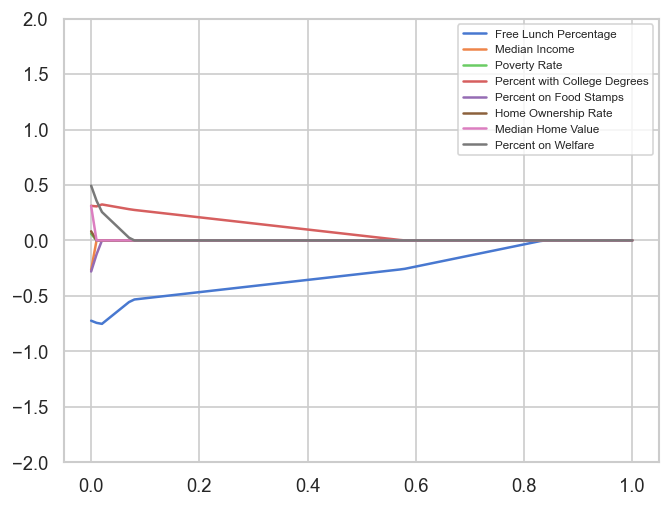

In [47]:
# ELA Lasso
df_scaled = final2.copy()

df_scaled = df_scaled.drop(columns=['COUNTYFIP_3', 'County Code', 'County Name'])

fullModelFormula = 'pct_met_ELA ~ ' + '+'.join(
    df_scaled.columns.drop(['pct_met_ELA', 'pct_met_Math'])
)

cols_to_standardize = ['pct_met_ELA', 'pct_met_Math', 'frpm_pct_free', 'median_income',
                       'poverty_rate', 'pct_bachelors_plus', 'pct_foodstmp',
                       'homeownership_rate', 'median_house_value', 'pct_welfare']

scaler = StandardScaler()
df_scaled[cols_to_standardize] = scaler.fit_transform(df_scaled[cols_to_standardize])

lambdas = np.arange(0, 1.01, 0.01)
coef = []
for lam in lambdas:
    coef.append(smf.ols(fullModelFormula, df_scaled).fit_regularized(alpha=lam, L1_wt=1).params)

nameMap = {
    'frpm_pct_free':      'Free Lunch Percentage',
    'median_income':      'Median Income',
    'poverty_rate':       'Poverty Rate',
    'pct_bachelors_plus': 'Percent with College Degrees',
    'pct_foodstmp':       'Percent on Food Stamps',
    'homeownership_rate': 'Home Ownership Rate',
    'median_house_value': 'Median Home Value',
    'pct_welfare':        'Percent on Welfare'
}

ax = pd.DataFrame(coef, lambdas).rename(columns=nameMap).drop(columns=['Intercept'], errors='ignore').plot(kind='line', ylim=(-2, 2))
ax.legend(loc='upper right', fontsize='xx-small')
ax

<Axes: >

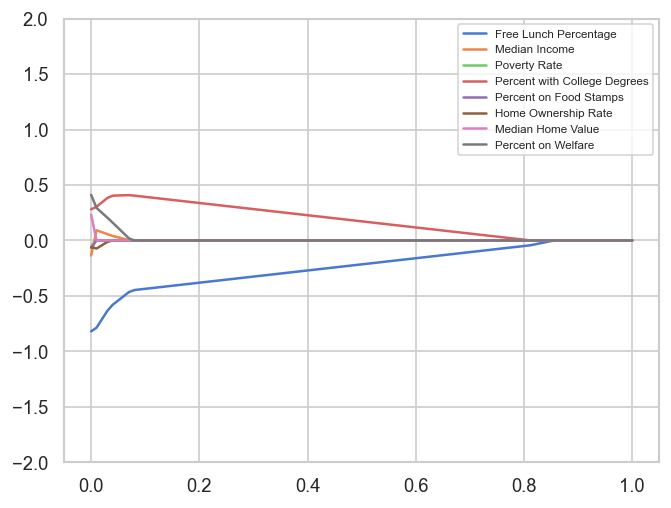

In [48]:
# Math Lasso
fullModelFormula_math = 'pct_met_Math ~ ' + '+'.join(
    df_scaled.columns.drop(['pct_met_ELA', 'pct_met_Math'])
)

lambdas = np.arange(0, 1.01, 0.01)
coef = []
for lam in lambdas:
    coef.append(smf.ols(fullModelFormula_math, df_scaled).fit_regularized(alpha=lam, L1_wt=1).params)

ax = pd.DataFrame(coef, lambdas).rename(columns=nameMap).drop(columns=['Intercept'], errors='ignore').plot(kind='line', ylim=(-2, 2))
ax.legend(loc='upper right', fontsize='xx-small')
ax

In [49]:
# Principal Component Analysis
pca = PCA(n_components=0.95)
x_transform = pca.fit_transform(df_scaled[['frpm_pct_free', 'median_income', 'poverty_rate',
                                            'pct_bachelors_plus', 'pct_foodstmp',
                                            'homeownership_rate', 'median_house_value', 'pct_welfare']])

pcaWeights = pd.DataFrame(
    pca.components_.T,
    index=['frpm_pct_free', 'median_income', 'poverty_rate', 'pct_bachelors_plus',
           'pct_foodstmp', 'homeownership_rate', 'median_house_value', 'pct_welfare'],
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)
pcaWeights

,PC1,PC2,PC3,PC4
frpm_pct_free,0.385942,-0.157063,-0.150121,-0.482935
median_income,-0.386894,-0.235048,0.317833,-0.049898
poverty_rate,0.362749,-0.212400,-0.144249,0.801346
pct_bachelors_plus,-0.376987,-0.289276,0.161136,0.285086
pct_foodstmp,0.392768,-0.100823,0.300396,-0.087463
homeownership_rate,-0.120988,0.779891,0.369551,0.150518
median_house_value,-0.363779,-0.374168,0.139788,-0.102677
pct_welfare,0.355551,-0.181362,0.763759,-0.002593


In [50]:
# ANOVA: Comparing the full model to subsets of the model to get the model
# with the fewest predictors which is still similar to the full model
# ELA

features = set(final2.columns.drop(['pct_met_ELA', 'pct_met_Math', 
                                     'County Code', 'County Name', 'COUNTYFIP_3']))

formulas = []
for i in range(1, len(features) + 1):
    for combo in combinations(features, i):
        formula = 'pct_met_ELA ~' + '+'.join(combo)
        formulas.append(formula)

fullModel = smf.ols(formulas[-1], final2).fit()
results_subset = []
for f in formulas[:-1]:
    reduced = smf.ols(f, final2).fit()
    anovaResult = anova_lm(reduced, fullModel)
    results_subset.append({
        'formula': f,
        'p_value': anovaResult['Pr(>F)'].iloc[1],
    })

results_subset = pd.DataFrame(results_subset).sort_values('p_value').reset_index(drop=True)

def n_terms(formula):
    rhs = formula.split('~')[1]
    return len([t for t in rhs.split('+') if t.strip() not in ('1', '')])

results_subset['n_terms'] = results_subset['formula'].apply(n_terms)

adequate = results_subset[results_subset['p_value'] > 0.05]        # not sig. different from full
smallest_adequate = adequate.sort_values('n_terms').iloc[0]
print(smallest_adequate['formula'])

pct_met_ELA ~frpm_pct_free


In [51]:
print(fullModel.summary())
reduced_ela = smf.ols('pct_met_ELA ~ frpm_pct_free', final2).fit()
print(reduced_ela.summary())

                            OLS Regression Results                            
Dep. Variable:            pct_met_ELA   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     12.77
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           4.11e-07
Time:                        14:32:38   Log-Likelihood:                -87.518
No. Observations:                  34   AIC:                             193.0
Df Residuals:                      25   BIC:                             206.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             57.0556     21

In [52]:
# Math
features = set(final2.columns.drop(['pct_met_ELA', 'pct_met_Math', 
                                     'County Code', 'County Name', 'COUNTYFIP_3']))

formulas = []
for i in range(1, len(features) + 1):
    for combo in combinations(features, i):
        formula = 'pct_met_Math ~' + '+'.join(combo)
        formulas.append(formula)

fullModel_math = smf.ols(formulas[-1], final2).fit()
results_subset_math = []
for f in formulas[:-1]:
    reduced = smf.ols(f, final2).fit()
    anovaResult = anova_lm(reduced, fullModel_math)
    results_subset_math.append({
        'formula': f,
        'p_value': anovaResult['Pr(>F)'].iloc[1],
    })

results_subset_math = pd.DataFrame(results_subset_math).sort_values('p_value').reset_index(drop=True)
results_subset_math['n_terms'] = results_subset_math['formula'].apply(n_terms)

adequate = results_subset_math[results_subset_math['p_value'] > 0.05]           # not sig. different from full
smallest_adequate = adequate.sort_values('n_terms').iloc[0]
print(smallest_adequate['formula'])

pct_met_Math ~frpm_pct_free+median_house_value


In [53]:
print(fullModel_math.summary())
reduced_math = smf.ols('pct_met_Math ~ frpm_pct_free + pct_welfare', final2).fit()
print(reduced_math.summary())

                            OLS Regression Results                            
Dep. Variable:           pct_met_Math   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     19.42
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           6.28e-09
Time:                        14:32:39   Log-Likelihood:                -88.826
No. Observations:                  34   AIC:                             195.7
Df Residuals:                      25   BIC:                             209.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             60.6163     22

In [54]:
# pct_bachelors_plus, pct_welfare seem to be the strongest variables

## 11. Variance Decomposition

In [55]:
# Partitions R² into school-level poverty (FRPM) vs neighborhood-level Census variables
# Helps find which group of variables explains more of the variance in test scores
# Model 1: FRPM only, Model 2: Census only, Model 3: Both combined

frpm_only = ['frpm_pct_free']
census_only = ['median_income', 'pct_bachelors_plus', 'pct_foodstmp', 
               'homeownership_rate', 'pct_welfare']
all_vars = frpm_only + census_only

outcomes = {'ELA': 'pct_met_ELA', 'Math': 'pct_met_Math'}
results = {}

for subject, outcome in outcomes.items():
    y = final2[outcome]
    
    # Model 1 — FRPM only
    X1 = sm.add_constant(final2[frpm_only])
    model1 = sm.OLS(y, X1).fit()
    
    # Model 2 — Census variables only
    X2 = sm.add_constant(final2[census_only])
    model2 = sm.OLS(y, X2).fit()
    
    # Model 3 — All variables combined
    X3 = sm.add_constant(final2[all_vars])
    model3 = sm.OLS(y, X3).fit()
    
    results[subject] = {
        'FRPM only R²': model1.rsquared,
        'Census only R²': model2.rsquared,
        'Combined R²': model3.rsquared,
        'Unique to FRPM': model3.rsquared - model2.rsquared,
        'Unique to Census': model3.rsquared - model1.rsquared,
    }

for subject, res in results.items():
    print(f"\n=== {subject} ===")
    for k, v in res.items():
        print(f"{k}: {round(v, 4)} ({round(v*100, 2)}%)")


=== ELA ===
FRPM only R²: 0.6988 (69.88%)
Census only R²: 0.7253 (72.53%)
Combined R²: 0.785 (78.5%)
Unique to FRPM: 0.0597 (5.97%)
Unique to Census: 0.0862 (8.62%)

=== Math ===
FRPM only R²: 0.7324 (73.24%)
Census only R²: 0.7795 (77.95%)
Combined R²: 0.8507 (85.07%)
Unique to FRPM: 0.0712 (7.12%)
Unique to Census: 0.1183 (11.83%)


In [ ]:
# Bar chart visualizing variance decomposition results
# Shows how much of test score variation each group of variables explains independently vs combined
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Variance Decomposition — What Explains Test Score Variation?', 
             fontsize=13, fontweight='bold')

for ax, (subject, res) in zip(axes, results.items()):
    categories = ['FRPM Only', 'Census Only', 'Combined']
    values = [res['FRPM only R²']*100, res['Census only R²']*100, res['Combined R²']*100]
    colors = ['steelblue', 'coral', 'mediumpurple']
    
    bars = ax.bar(categories, values, color=colors, edgecolor='white', alpha=0.85)
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.set_ylabel('R² (%)', fontsize=11)
    ax.set_title(f'{subject} Scores', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.axhline(y=100, color='black', linewidth=0.5, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURE_DIR}/variance_decomposition.png', bbox_inches='tight')
plt.show()
print("Saved")

## 12. Linear Regression

In [57]:
# OLS regression predicting ELA and Math scores from final set of 6 predictors
# p-values indicate which predictors are statistically significant (p < 0.05)
# R² indicates overall model fit how much variance is explained

# Define predictors and outcomes
X = sm.add_constant(final2[['frpm_pct_free', 'median_income', 'pct_bachelors_plus', 
                              'pct_foodstmp', 'homeownership_rate', 'pct_welfare']])
y_ela  = final2['pct_met_ELA']
y_math = final2['pct_met_Math']

# Fit models separately for ELA and Math
model_ela  = sm.OLS(y_ela, X).fit()
model_math = sm.OLS(y_math, X).fit()

print("=" * 60)
print("ELA REGRESSION RESULTS")
print("=" * 60)
print(model_ela.summary())

print("\n")
print("=" * 60)
print("MATH REGRESSION RESULTS")
print("=" * 60)
print(model_math.summary())

ELA REGRESSION RESULTS
                            OLS Regression Results                            
Dep. Variable:            pct_met_ELA   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     16.43
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           6.99e-08
Time:                        14:32:40   Log-Likelihood:                -89.033
No. Observations:                  34   AIC:                             192.1
Df Residuals:                      27   BIC:                             202.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const        

In [58]:
# Standardize predictors to compare coefficients on the same scale
# Standardized coefficients show which predictor has the largest effect regardless of units
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(final2[['frpm_pct_free', 'median_income', 'pct_bachelors_plus', 
                                  'pct_foodstmp', 'homeownership_rate', 'pct_welfare']]),
    columns=['frpm_pct_free', 'median_income', 'pct_bachelors_plus', 
             'pct_foodstmp', 'homeownership_rate', 'pct_welfare']
)

# Refit models with standardized predictors
X_scaled_const = sm.add_constant(X_scaled)
model_ela_std  = sm.OLS(final2['pct_met_ELA'],  X_scaled_const).fit()
model_math_std = sm.OLS(final2['pct_met_Math'], X_scaled_const).fit()

print("ELA Standardized Coefficients:")
print(pd.DataFrame({
    'coef': model_ela_std.params.drop('const').round(3),
    'p-value': model_ela_std.pvalues.drop('const').round(3)
}))

print("\nMath Standardized Coefficients:")
print(pd.DataFrame({
    'coef': model_math_std.params.drop('const').round(3),
    'p-value': model_math_std.pvalues.drop('const').round(3)
}))

ELA Standardized Coefficients:
                     coef  p-value
frpm_pct_free      -5.522    0.011
median_income      -0.128    0.945
pct_bachelors_plus  2.146    0.369
pct_foodstmp       -1.450    0.453
homeownership_rate -0.090    0.934
pct_welfare         3.110    0.026

Math Standardized Coefficients:
                     coef  p-value
frpm_pct_free      -7.466    0.001
median_income       0.936    0.627
pct_bachelors_plus  2.243    0.363
pct_foodstmp       -0.515    0.795
homeownership_rate -0.925    0.410
pct_welfare         3.207    0.026


In [ ]:
# Standardized coefficient plot
# blue = statistically significant (p < 0.05), gray = not significant
# Confidence intervals shown as horizontal lines if they cross zero the effect is not significant
# * p < 0.05, ** p < 0.01, *** p < 0.001
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Standardized OLS Regression Coefficients — ELA and Math Scores', 
             fontsize=13, fontweight='bold')

predictors_labels = {
    'frpm_pct_free': 'FRPM Free Meal Rate',
    'median_income': 'Median Income',
    'pct_bachelors_plus': "% Bachelor's+",
    'pct_foodstmp': 'SNAP Rate',
    'homeownership_rate': 'Homeownership Rate',
    'pct_welfare': 'Welfare Rate'
}

for ax, (subject, model) in zip(axes, [('ELA', model_ela_std), ('Math', model_math_std)]):
    params = model.params.drop('const')
    conf   = model.conf_int().drop('const')
    pvals  = model.pvalues.drop('const')
    
    params.index = [predictors_labels[i] for i in params.index]
    conf.index   = params.index
    pvals.index  = params.index
    
    colors = ['steelblue' if p < 0.05 else 'lightgray' for p in pvals]
    
    ax.barh(params.index, params.values, color=colors, edgecolor='white', alpha=0.85)
    
    for i, (idx, row) in enumerate(conf.iterrows()):
        ax.plot([row[0], row[1]], [i, i], color='black', linewidth=1.5)
        ax.plot([row[0], row[0]], [i-0.1, i+0.1], color='black', linewidth=1.5)
        ax.plot([row[1], row[1]], [i-0.1, i+0.1], color='black', linewidth=1.5)
    
    ax.axvline(x=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_xlabel('Standardized Coefficient', fontsize=10)
    ax.set_title(f'{subject} (R² = {model.rsquared:.3f})', fontsize=11, fontweight='bold')
    
    for i, (p, v) in enumerate(zip(pvals, params.values)):
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if sig:
            offset = 0.2 if v >= 0 else -0.2
            ax.text(v + offset, i, f'{sig}', va='center', fontsize=12, 
                   color='crimson', fontweight='bold')

legend_elements = [Patch(facecolor='steelblue', label='Significant (p < 0.05)'),
                   Patch(facecolor='lightgray', label='Not significant')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURE_DIR}/regression_coefficients_standardized.png', bbox_inches='tight')
plt.show()
print("Saved")

## 13. Regression Diagnostics

In [ ]:
# Residuals vs Fitted: checks linearity and homoscedasticity assumptions
# points should be randomly scattered around zero with no pattern
# Q-Q Plot: checks normality of residuals assumption
# points should fall closely along the diagonal line

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regression Diagnostics', fontsize=13, fontweight='bold')

for row, (subject, model) in enumerate([('ELA', model_ela), ('Math', model_math)]):
    fitted    = model.fittedvalues
    residuals = model.resid

    # Residuals vs Fitted
    axes[row, 0].scatter(fitted, residuals, color='steelblue', alpha=0.7, edgecolors='white')
    axes[row, 0].axhline(y=0, color='crimson', linewidth=1.5, linestyle='--')
    axes[row, 0].set_xlabel('Fitted Values', fontsize=9)
    axes[row, 0].set_ylabel('Residuals', fontsize=9)
    axes[row, 0].set_title(f'{subject} — Residuals vs Fitted', fontsize=10, fontweight='bold')

    # Q-Q plot — tests normality of residuals
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
    axes[row, 1].scatter(osm, osr, color='steelblue', alpha=0.7, edgecolors='white')
    axes[row, 1].plot(osm, slope*np.array(osm)+intercept, color='crimson', linewidth=1.5)
    axes[row, 1].set_xlabel('Theoretical Quantiles', fontsize=9)
    axes[row, 1].set_ylabel('Sample Quantiles', fontsize=9)
    axes[row, 1].set_title(f'{subject} — Q-Q Plot', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_FIGURE_DIR}/regression_diagnostics.png', bbox_inches='tight')
plt.show()
print("Saved")